In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx

from netCDF4 import Dataset
import geopandas as gpd
from shapely.geometry import Point
from pyproj import CRS, Transformer

from scipy.interpolate import interp1d
from scipy.stats import linregress, ks_2samp

from pymannkendall import original_test as mk_test

from utils import process_events

pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
hydroDir = "/eos/jeodpp/data/projects/CLIMEX/CFRisks/CFRisks_data/"

In [3]:
NUTS3 = gpd.read_file(f"{hydroDir}/NUTS3/NUTS3_modified.shp")
NutVector = NUTS3['NUTS_ID'].tolist()

In [4]:
Hanze_flood = pd.read_csv(f"{hydroDir}/HANZE/HANZE_events.csv")
Hanze_flood_1980 = Hanze_flood[Hanze_flood['Year'] > 1980]
Hanze_flood_1980 = Hanze_flood_1980[Hanze_flood_1980['Type'] != "Coastal"]
list_of_word_vectors = [regions.split(';') for regions in Hanze_flood['Regions affected (v2021)']]

In [5]:
len(Hanze_flood_1980)

1349

In [6]:
fl_events = pd.read_csv(f"{hydroDir}/hazard_data/fl_nuts3_v1.csv", index_col=0)
fl_events['enddate'] = pd.to_datetime(fl_events['enddate'])
fl_events['stardate'] = fl_events['enddate'] - pd.to_timedelta(fl_events['duration'], unit='D')

In [7]:
dr_events = pd.read_csv(f"{hydroDir}/hazard_data/dr_nuts3_v1.csv", index_col=0)
dr_events['stardate'] = pd.to_datetime(dr_events['stardate'], format="%d/%m/%Y")
dr_events['enddate'] = pd.to_datetime(dr_events['enddate'], format="%d/%m/%Y")
dr_events['duration'] = (dr_events['enddate'] - dr_events['stardate']).dt.days+1

In [8]:
dr_events = pd.read_csv(f"{hydroDir}/hazard_data/dr_nuts3_v1.csv", index_col=0)
dr_events['stardate'] = pd.to_datetime(dr_events['stardate'], format="%d/%m/%Y")
dr_events['enddate'] = pd.to_datetime(dr_events['enddate'], format="%d/%m/%Y")
dr_events['stardate'] = pd.to_datetime(dr_events['stardate'], format="%d/%m/%Y")
dr_events['enddate'] = pd.to_datetime(dr_events['enddate'], format="%d/%m/%Y")
dr_events['duration'] = (dr_events['enddate'] - dr_events['stardate']).dt.days+1
dr_events = dr_events[dr_events["duration"] >= 10]

In [9]:
dr_events.groupby

<bound method DataFrame.groupby of        threshold  percentile  low_peaks   stardate    enddate  ipeaks  \
1       0.159602           5    0.02124 1980-01-13 1980-01-22      21   
4       0.161896           5    0.04799 1982-01-26 1982-02-17     757   
7       0.281662           5    0.00708 1983-04-29 1983-06-05    1238   
10      0.169066           5    0.04957 1983-11-06 1983-12-10    1440   
13      0.159279           5    0.00315 1984-11-09 1985-01-21    1847   
...          ...         ...        ...        ...        ...     ...   
82146   0.176299           5    0.03855 2011-11-16 2011-12-04   11648   
82147   0.609703           5    0.00865 2012-01-19 2012-02-18   11736   
82149   0.214953           5    0.05429 2012-06-18 2012-07-01   11871   
82150   0.203151           5    0.04406 2013-12-18 2014-01-05   12407   
82151   2.455578           5    0.01023 2014-03-23 2014-04-14   12517   

             time  cluster_length  merged_subclusters    NUT  duration  
1      21/01/19

In [10]:

grouped_events = dr_events.groupby('NUT').size().reset_index(name='droughts')
grouped_events.rename(columns={'NUT': 'NUTS_ID'}, inplace=True)


In [11]:
NUTS3_2021 = gpd.read_file(f"{hydroDir}/NUTS3/Regions_v2021_simplified.shp")

droughts_plot = NUTS3_2021.merge(
    grouped_events,
    left_on='Code',
    right_on='NUTS_ID',
    how='left'
)

# Replace 0 with NaN for transparency in the plot
droughts_plot.loc[droughts_plot['droughts'] == 0, 'droughts'] = np.nan


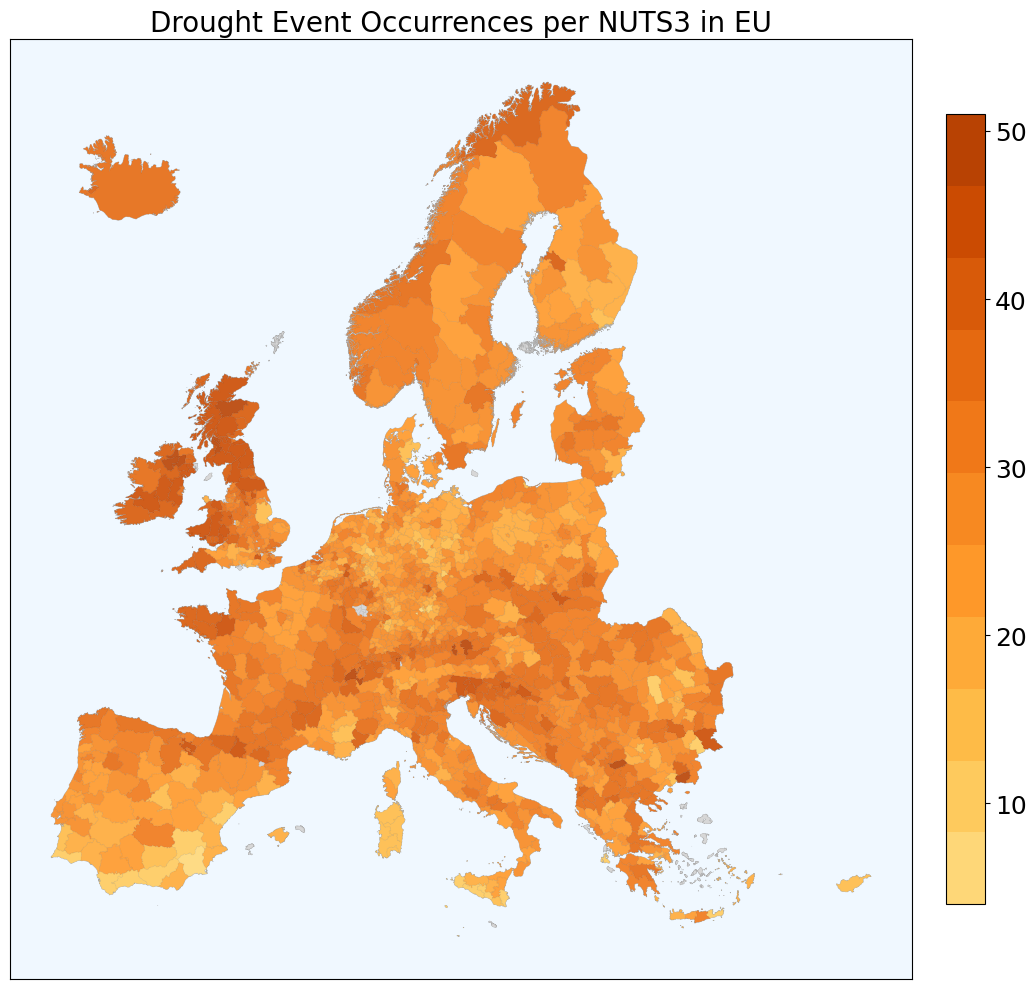

In [12]:
# Define a lighter or dark yellow colormap
paletf = plt.cm.YlOrBr(np.linspace(0.3, 0.8, 11))  # Use YlOrBr for lighter yellow-orange shades
cmap = mcolors.ListedColormap(paletf)

# Plot setup
fig, ax = plt.subplots(figsize=(12, 10))

# Base map with subtle borders
NUTS3_2021.plot(ax=ax, facecolor='white', edgecolor='darkgrey', linewidth=0.5)

# Plot the drought occurrences without borders
droughts_plot.plot(
    ax=ax,
    column='droughts',
    cmap=cmap,
    alpha=0.9,
    edgecolor='none',
    missing_kwds={'color': 'lightgrey'}
)

# Add a color bar
vmin = droughts_plot['droughts'].min(skipna=True)
vmax = droughts_plot['droughts'].max(skipna=True)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array(droughts_plot['droughts'])

cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.03)
#cbar.set_label("Number of Events", fontsize=20)
cbar.ax.tick_params(labelsize=18)

# Aesthetics
ax.set_facecolor('aliceblue')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title("Drought Event Occurrences per NUTS3 in EU", fontsize=20)

plt.tight_layout()
plt.show()


In [13]:

IDrought = 56
windows = ["informed"]  # just one for simplicity; can extend if needed

# --- Minimum drought durations to test ---
min_durations = [1, 7, 10, 14]  # 0 = no filter (baseline)

# --- Container for results ---
drought_match_results = {}

# --- Loop over duration thresholds ---
for min_dur in min_durations:
    print(f"\n=== Processing droughts with min duration ≥{min_dur} days ===")

    # Filter drought events
    if min_dur > 1:
        dr_events_filtered = dr_events[dr_events["duration"] >= min_dur].copy()
    else:
        dr_events_filtered = dr_events.copy()

    list_POTl_large = []

    # --- Only need the informed window ---
    for w in windows:
        wdrought = IDrought
        df_POTl_large_w = pd.DataFrame()

        for NUTl in NutVector:
            # Subset events per region
            High_events = fl_events[fl_events["NUT"] == NUTl]
            if not High_events.empty:
                Low_events = dr_events_filtered[dr_events_filtered["NUT"] == NUTl]

                # Match HANZE rows for this NUT
                matches = [NUTl in vec for vec in list_of_word_vectors]
                tm = [i for i, val in enumerate(matches) if val]
                Hanze_Nut = Hanze_flood.iloc[tm]
                Hanze_Nut = Hanze_Nut[Hanze_Nut["Year"] > 1980].copy()
                Hanze_Nut["eid"] = Hanze_Nut["ID"]

                df_POTl_keep = pd.DataFrame()

                for e, eid in enumerate(Hanze_Nut["ID"]):
                    POTl_keep = process_events(
                        events_df=Low_events,
                        reference_df=Hanze_Nut,
                        event_idx=e,
                        window=wdrought,
                        nut_id=NUTl,
                        haz="drought",
                    )
                    df_POTl_keep = pd.concat([df_POTl_keep, POTl_keep], ignore_index=True)

                df_POTl_large_w = pd.concat([df_POTl_large_w, df_POTl_keep], ignore_index=True)

        df_POTl_large_w["NEID"] = df_POTl_large_w["eventID"].astype(str) + df_POTl_large_w["NUTID"]

        # Store results
        drought_match_results[min_dur] = df_POTl_large_w




=== Processing droughts with min duration ≥1 days ===

=== Processing droughts with min duration ≥7 days ===

=== Processing droughts with min duration ≥10 days ===

=== Processing droughts with min duration ≥14 days ===


In [14]:
len(df_POTl_large_w)

528

In [15]:
# --- Optional: Combine summary stats ---
summary = []
for min_dur, df in drought_match_results.items():
    n_matches = len(df)
    n_unique_floods = df["eventID"].nunique()
    mean_length = dr_events[dr_events["duration"] >= min_dur]["duration"].mean()
    summary.append({
        "min_duration_days": min_dur,
        "n_compound_drought_flood": n_matches,
        "n_unique_floods": n_unique_floods,
        "mean_drought_length": mean_length,
    })

summary_df = pd.DataFrame(summary)


In [16]:
summary_df

,min_duration_days,n_compound_drought_flood,n_unique_floods,mean_drought_length
0,1,624,299,44.069306
1,7,624,299,44.069306
2,10,624,299,44.069306
3,14,528,261,50.837232


In [17]:

merged_results = {}

# Loop over each drought dataset
for key, drought_df in drought_match_results.items():
    print(f"Processing drought dataset: {key}")

    # 1. Merge matched drought-flood events with flood data
    drought_merged = pd.merge(
        drought_df,
        Hanze_flood_1980,
        left_on="eventID",
        right_on="ID",
        how="left"
    )

    # 2. Create a list of eventIDs that appear in this drought compound dataset
    drought_event_ids = set(drought_df["eventID"].unique())

    # 3. Count number of drought co-occurrences per flood event
    drought_counts = drought_df["eventID"].value_counts().rename_axis("eventID").reset_index(name="predrought")

    # 4. Merge counts with full flood dataset
    merged = Hanze_flood_1980.merge(
        drought_counts,
        left_on="ID",
        right_on="eventID",
        how="left"
    )

    # 5. Define `single` = 1 for floods NOT associated with droughts
    merged["single"] = (~merged["ID"].isin(drought_event_ids)).astype(int)

    # 6. Fill NaN in predrought (for singles) with 0
    merged["predrought"] = merged["predrought"].fillna(0).astype(int)

    # 7. Store final dataset
    merged_results[key] = merged


Processing drought dataset: 1
Processing drought dataset: 7
Processing drought dataset: 10
Processing drought dataset: 14


In [18]:
merged_results.keys()

dict_keys([1, 7, 10, 14])

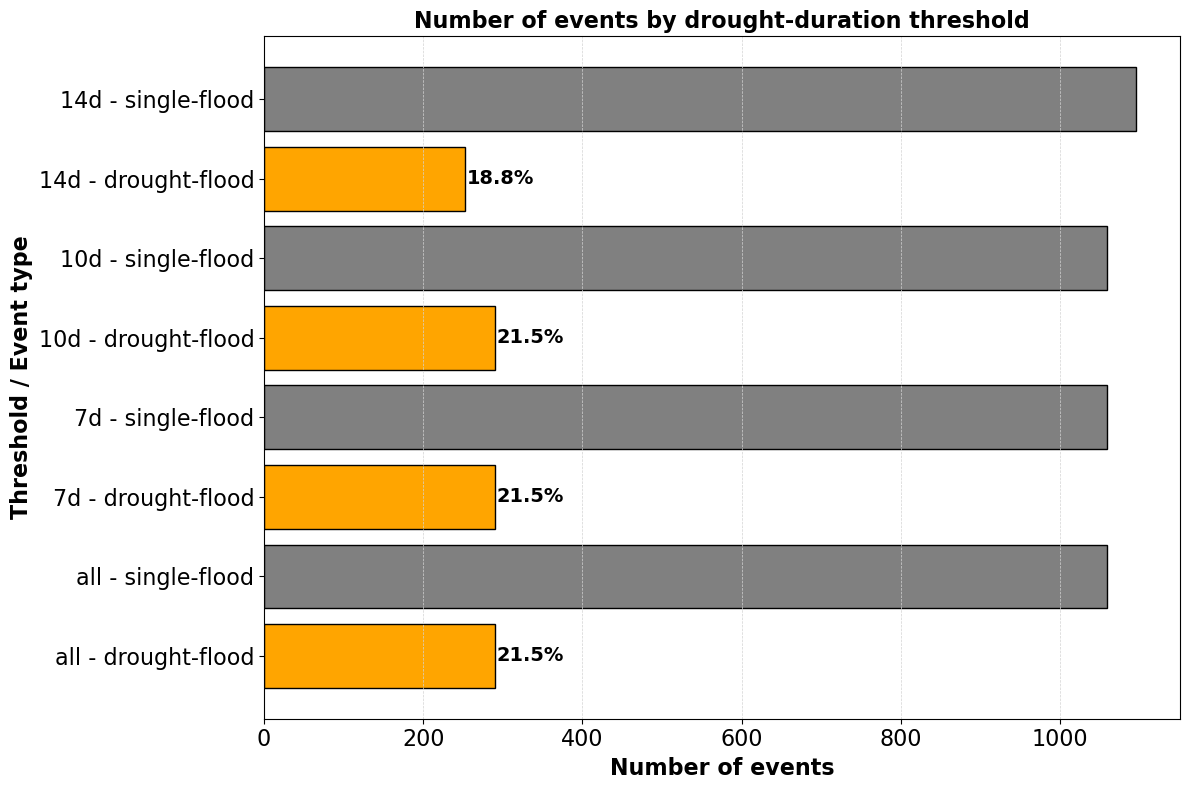

In [19]:


# Original dict with numeric keys
merged_results.keys()  # dict_keys([1, 7, 10, 14])

# Mapping numeric keys to labels
key_labels = {1: "all", 7: "7d", 10: "10d", 14: "14d"}

# Loop using labels
threshold_labels = ["all", "7d", "10d", "14d"]

# Example: rename keys in merged_results for easier plotting
merged_results_labeled = {key_labels[k]: v for k, v in merged_results.items()}


# Colors
color_mapping = {
    "single-flood": "gray",
    "drought-flood": "orange",
}

# Prepare data for plotting
bar_data = []
for key in threshold_labels:
    df = merged_results_labeled[key]
    n_predrought = (df['predrought'] > 0).sum()
    n_single = (df['single'] == 1).sum()
    total = n_predrought + n_single
    bar_data.append({"threshold": key, "type": "drought-flood", "count": n_predrought, "total": total})
    bar_data.append({"threshold": key, "type": "single-flood", "count": n_single, "total": total})

bar_df = pd.DataFrame(bar_data)

# Horizontal bar plot
plt.figure(figsize=(12,8))
y_pos = 0
yticks = []

for key in threshold_labels:
    subset = bar_df[bar_df["threshold"]==key]
    for i, row in subset.iterrows():
        plt.barh(y=y_pos, width=row["count"], color=color_mapping[row["type"]], edgecolor='black')
        # Add percentage label for drought-flood only
        if row["type"] == "drought-flood":
            pct = 100*row["count"]/row["total"]
            plt.text(row["count"] + 2, y_pos, f"{pct:.1f}%", va='center', fontsize=14, fontweight='bold')
        yticks.append(f"{key} - {row['type']}")
        y_pos += 1

plt.yticks(range(len(yticks)), yticks)
plt.xlabel("Number of events", fontsize=16, fontweight='bold')
plt.ylabel("Threshold / Event type", fontsize=16, fontweight='bold')
plt.tick_params(axis='both', labelsize=16)
plt.title("Number of events by drought-duration threshold", fontsize=16, fontweight='bold')
plt.grid(axis='x', color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [20]:
bar_df 

,threshold,type,count,total
0,all,drought-flood,290,1349
1,all,single-flood,1059,1349
2,7d,drought-flood,290,1349
3,7d,single-flood,1059,1349
4,10d,drought-flood,290,1349
5,10d,single-flood,1059,1349
6,14d,drought-flood,253,1349
7,14d,single-flood,1096,1349


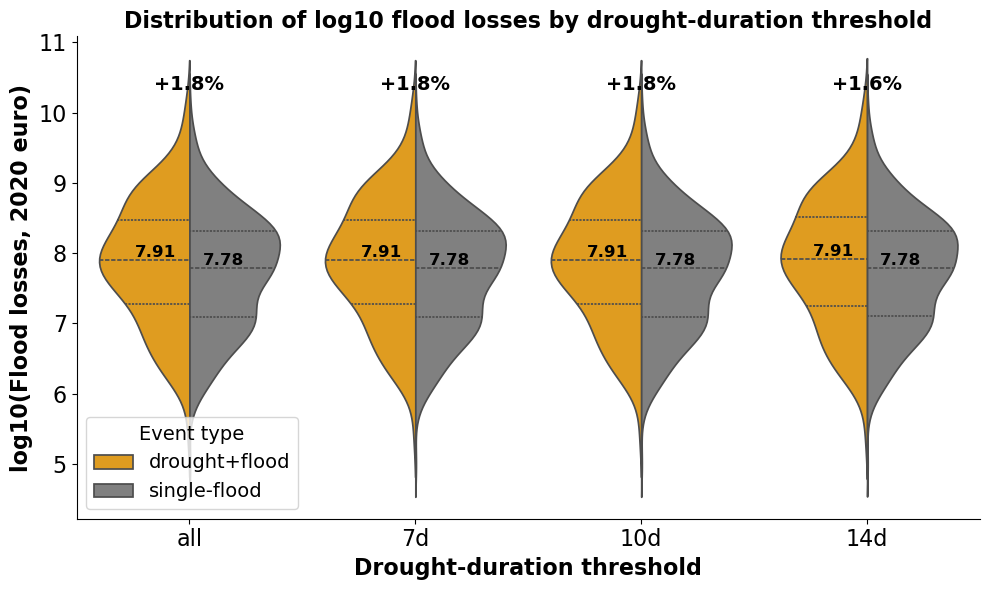

In [21]:


violin_data = []

for key in threshold_labels:
    df = merged_results_labeled[key]
    
    # Compound drought-flood
    log_loss_comp = np.log10(df.loc[df['predrought']>0, 'Losses (2020 euro)'].clip(lower=1))
    for val in log_loss_comp:
        violin_data.append({"threshold": key, "type": "drought+flood", "log_loss": val})
    
    # Single flood
    log_loss_single = np.log10(df.loc[df['single']==1, 'Losses (2020 euro)'].clip(lower=1))
    for val in log_loss_single:
        violin_data.append({"threshold": key, "type": "single-flood", "log_loss": val})

violin_df = pd.DataFrame(violin_data)

# Color mapping
color_mapping = {"drought+flood": "orange", "single-flood": "gray"}

# --- Prepare summary statistics ---
summary_stats = violin_df.groupby(['threshold','type'])['log_loss'].median().reset_index()

# --- Compute percentage differences of mean log-loss ---
pct_diffs = {}

for t in threshold_labels:
    mean_comp = violin_df.loc[
        (violin_df['threshold'] == t) & (violin_df['type'] == "drought+flood"),
        "log_loss"
    ].mean()

    mean_single = violin_df.loc[
        (violin_df['threshold'] == t) & (violin_df['type'] == "single-flood"),
        "log_loss"
    ].mean()

    pct_diffs[t] = 100 * (mean_comp - mean_single) / mean_single


# --- Compute KS-test pairwise p-values across thresholds ---
ks_results = {}
for etype in ['drought+flood','single-flood']:
    ks_results[etype] = []
    for i in range(len(threshold_labels)-1):
        t1, t2 = threshold_labels[i], threshold_labels[i+1]
        data1 = violin_df.loc[(violin_df['threshold']==t1) & (violin_df['type']==etype), 'log_loss']
        data2 = violin_df.loc[(violin_df['threshold']==t2) & (violin_df['type']==etype), 'log_loss']
        ks_stat, p_val = ks_2samp(data1, data2)
        ks_results[etype].append((t1, t2, ks_stat, p_val))

# --- Plot violin ---
plt.figure(figsize=(10,6))
sns.violinplot(
    x="threshold",
    y="log_loss",
    hue="type",
    data=violin_df,
    palette=color_mapping,
    split=True,
    inner="quartile"
)

# --- Annotate medians ---
for i, row in summary_stats.iterrows():
    x_pos = threshold_labels.index(row['threshold'])
    x_offset = -0.15 if row['type']=="drought+flood" else 0.15
    plt.text(x_pos + x_offset, row['log_loss'], f"{row['log_loss']:.2f}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# --- Annotate % differences ---
for i, t in enumerate(threshold_labels):
    if t in pct_diffs:
        plt.text(i, 
                 violin_df['log_loss'].max() + 0.15,
                 f"{pct_diffs[t]:+.1f}%",
                 ha='center', va='bottom',
                 fontsize=14, fontweight='bold')


plt.xlabel("Drought-duration threshold", fontsize=16, fontweight='bold')
plt.ylabel("log10(Flood losses, 2020 euro)", fontsize=16, fontweight='bold')
plt.tick_params(axis='both', labelsize=16)
plt.title("Distribution of log10 flood losses by drought-duration threshold", fontsize=16, fontweight='bold')
plt.legend(title="Event type", fontsize=14, title_fontsize=14, loc="lower left")
sns.despine()
plt.tight_layout()
plt.show()


In [22]:
dr_events_filtered = dr_events[dr_events["duration"] >= 10].copy()

In [23]:
dr_events_filtered

,threshold,percentile,low_peaks,stardate,enddate,ipeaks,time,cluster_length,merged_subclusters,NUT,duration
1,0.159602,5,0.02124,1980-01-13,1980-01-22,21,21/01/1980,10,1,HR064,10
4,0.161896,5,0.04799,1982-01-26,1982-02-17,757,26/01/1982,23,2,HR064,23
7,0.281662,5,0.00708,1983-04-29,1983-06-05,1238,22/05/1983,38,3,HR064,38
10,0.169066,5,0.04957,1983-11-06,1983-12-10,1440,10/12/1983,35,3,HR064,35
13,0.159279,5,0.00315,1984-11-09,1985-01-21,1847,20/01/1985,74,3,HR064,74
...,...,...,...,...,...,...,...,...,...,...,...
82146,0.176299,5,0.03855,2011-11-16,2011-12-04,11648,21/11/2011,19,3,XK007,19
82147,0.609703,5,0.00865,2012-01-19,2012-02-18,11736,17/02/2012,31,3,XK007,31
82149,0.214953,5,0.05429,2012-06-18,2012-07-01,11871,01/07/2012,14,1,XK007,14
82150,0.203151,5,0.04406,2013-12-18,2014-01-05,12407,19/12/2013,19,3,XK007,19


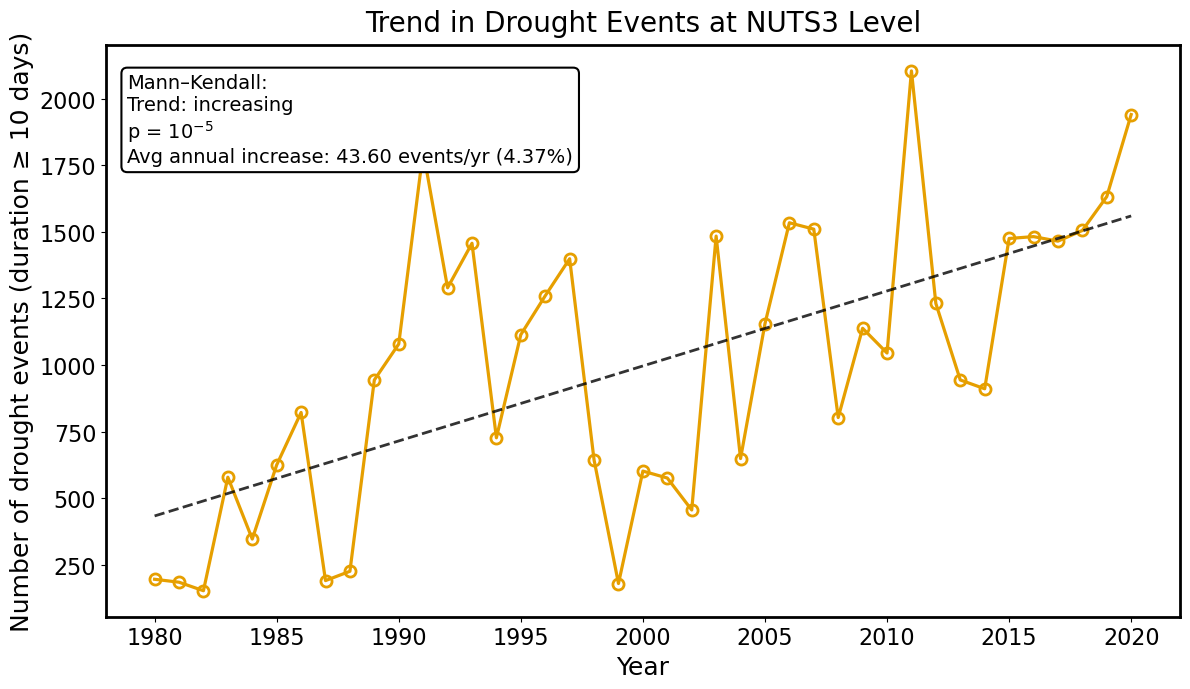

In [24]:



# ---------------------------------------------------------
# 1) PREPARE DATA
# ---------------------------------------------------------

# Ensure stardate is datetime
dr_events_filtered["stardate"] = pd.to_datetime(dr_events_filtered["stardate"])

# Extract year
dr_events_filtered["year"] = dr_events_filtered["stardate"].dt.year

# Count events per year
events_per_year = (
    dr_events_filtered.groupby("year")
    .size()
    .reset_index(name="n_events")
)

# Sorted by year (important for trend calculations)
events_per_year = events_per_year.sort_values("year")

# ---------------------------------------------------------
# 2) TREND STATISTICS
# ---------------------------------------------------------

# Compute differences to get average annual increase
diffs = events_per_year["n_events"].diff().dropna()
avg_annual_increase = diffs.mean()

# Percent relative to mean number of yearly events
mean_events = events_per_year["n_events"].mean()
annual_pct_change = (avg_annual_increase / mean_events) * 100

# Mann–Kendall monotonic trend test
mk_result = mk_test(events_per_year["n_events"])

trend_txt = "increasing" if mk_result.trend == "increasing" else \
            "decreasing" if mk_result.trend == "decreasing" else "no trend"

def format_p_scientific(p):
    if p == 0:
        return r"$10^{-300}$"
    exponent = int(np.floor(np.log10(p)))
    return fr"$10^{{{exponent}}}$"

p_formatted = format_p_scientific(mk_result.p)

# ---------------------------------------------------------
# 3) FITTED LINE (simple linear regression)
# ---------------------------------------------------------

years = events_per_year["year"].values
counts = events_per_year["n_events"].values

slope, intercept, r_value, p_lin, stderr = linregress(years, counts)
trendline = intercept + slope * years

# ---------------------------------------------------------
# 4) PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# Main line
plt.plot(
    years,
    counts,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2.0,
    markeredgecolor="#E69F00", 
    linewidth=2.3,
    color="#E69F00",
)

# Fitted trendline (black dashed)
plt.plot(
    years,
    trendline,
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.8,
)

# Labels
plt.xlabel("Year", fontsize=18)
plt.ylabel("Number of drought events (duration ≥ 10 days)", fontsize=18)
plt.title("Trend in Drought Events at NUTS3 Level", fontsize=20, pad=10)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Thicker axis spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ---------------------------------------------------------
# 5) ANNOTATION BOX
# ---------------------------------------------------------

annotation = (
    "Mann–Kendall:\n"
    f"Trend: {trend_txt}\n"
    f"p = {p_formatted}\n"
    f"Avg annual increase: {avg_annual_increase:.2f} events/yr "
    f"({annual_pct_change:.2f}%)"
)

plt.text(
    0.02, 0.95, annotation,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()



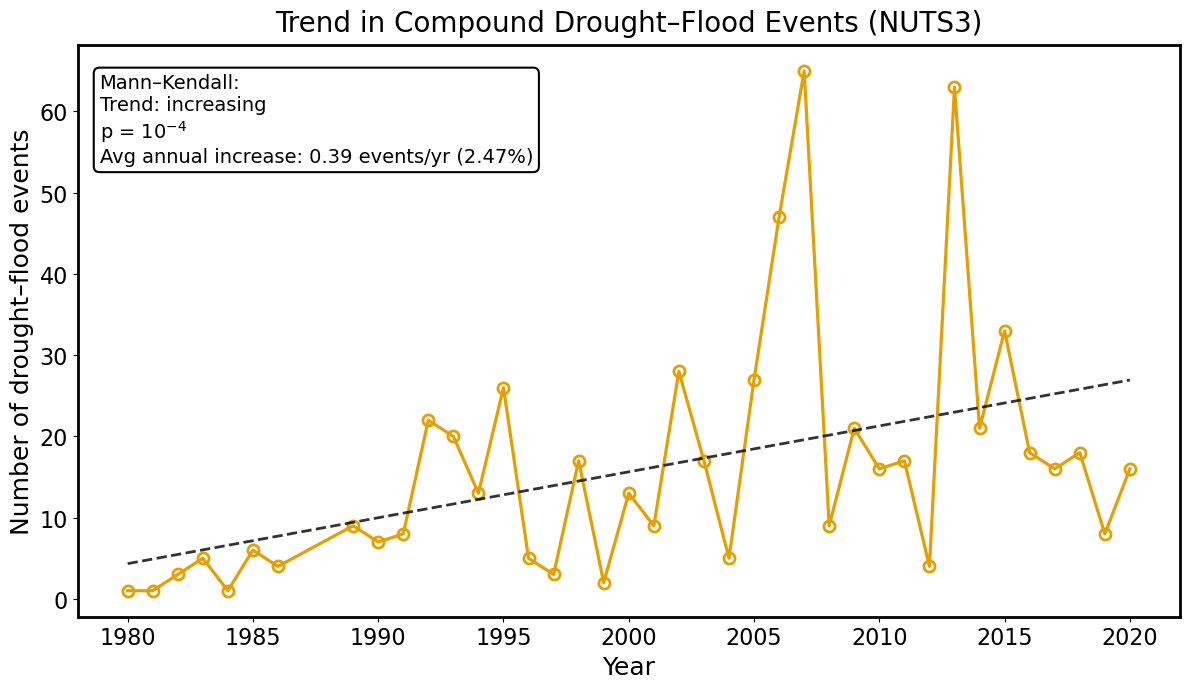

In [25]:

# ---------------------------------------------------------
# 1) PREPARE DATA
# ---------------------------------------------------------

df = drought_match_results[10].copy()

# Ensure stardate is datetime
df["stardate"] = pd.to_datetime(df["stardate"])

# Extract year
df["year"] = df["stardate"].dt.year

# Count events per year
events_per_year = (
    df.groupby("year")
      .size()
      .reset_index(name="n_events")
      .sort_values("year")
)

# ---------------------------------------------------------
# 2) TREND STATISTICS
# ---------------------------------------------------------

# Average annual increase (simple diff)
diffs = events_per_year["n_events"].diff().dropna()
avg_annual_increase = diffs.mean()

# Percent increase relative to mean
mean_events = events_per_year["n_events"].mean()
annual_pct_change = (avg_annual_increase / mean_events) * 100

# Mann–Kendall test
mk_result = mk_test(events_per_year["n_events"])

trend_txt = (
    "increasing" if mk_result.trend == "increasing"
    else "decreasing" if mk_result.trend == "decreasing"
    else "no trend"
)

# p-value as 10^{-x}
def format_p_scientific(p):
    if p == 0:
        return r"$10^{-300}$"
    exponent = int(np.floor(np.log10(p)))
    return fr"$10^{{{exponent}}}$"

p_formatted = format_p_scientific(mk_result.p)

# ---------------------------------------------------------
# 3) FIT LINEAR TREND
# ---------------------------------------------------------

years = events_per_year["year"].values
counts = events_per_year["n_events"].values

slope, intercept, rvalue, p_lin, stderr = linregress(years, counts)
trendline = intercept + slope * years

# ---------------------------------------------------------
# 4) PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# Main line
plt.plot(
    years, counts,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2,
    markeredgecolor="#E69F00",
    linewidth=2.3,
    color="#E69F00"
)

# Trendline
plt.plot(
    years, trendline,
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.8
)

# Labels
plt.xlabel("Year", fontsize=18)
plt.ylabel("Number of drought–flood events", fontsize=18)
plt.title("Trend in Compound Drought–Flood Events (NUTS3)", fontsize=20, pad=10)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Thicker borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ---------------------------------------------------------
# 5) ANNOTATION BOX
# ---------------------------------------------------------

annotation = (
    "Mann–Kendall:\n"
    f"Trend: {trend_txt}\n"
    f"p = {p_formatted}\n"
    f"Avg annual increase: {avg_annual_increase:.2f} events/yr "
    f"({annual_pct_change:.2f}%)"
)

plt.text(
    0.02, 0.95, annotation,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()


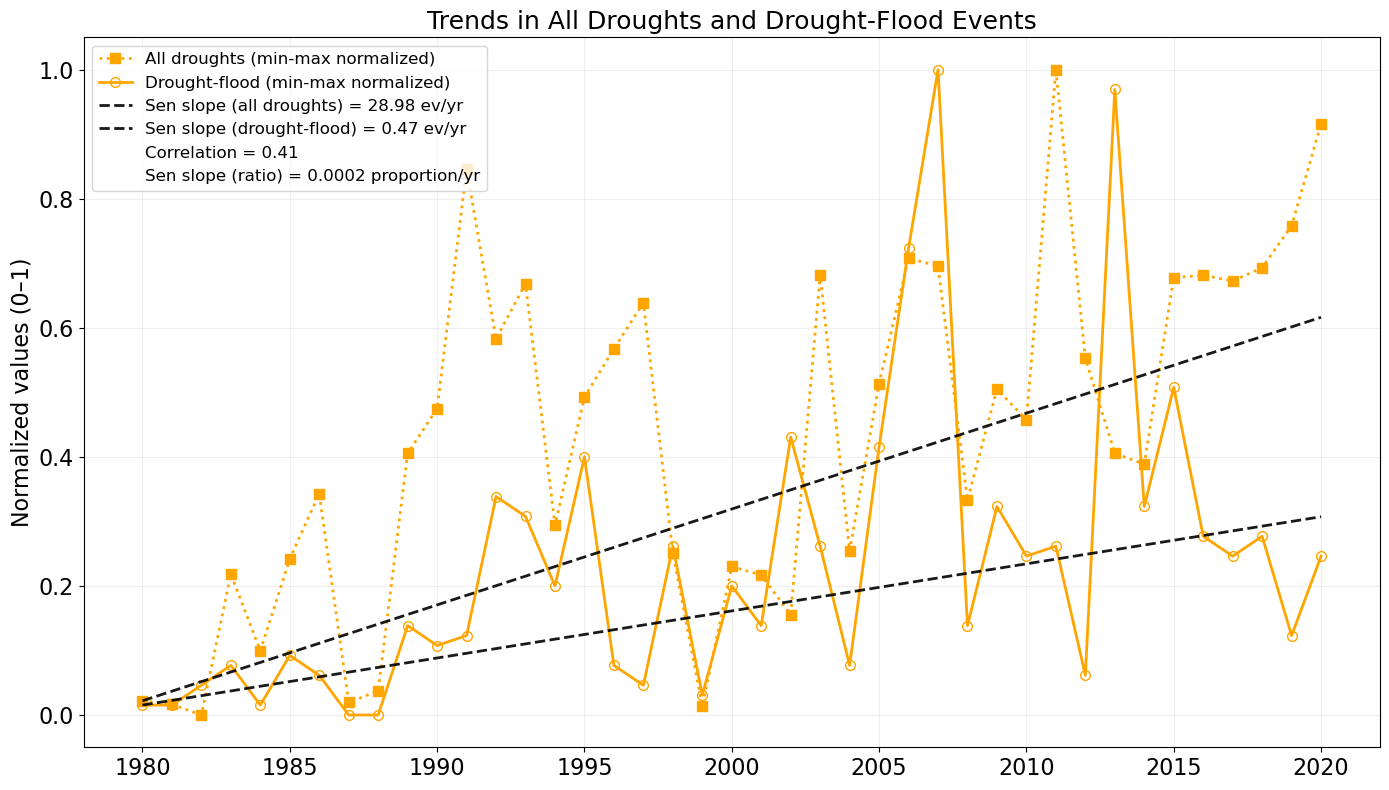

Droughts MK Test: Mann_Kendall_Test(trend='increasing', h=True, p=1.7797365767346918e-05, z=4.290871031663777, Tau=0.46707317073170734, s=383.0, var_s=7925.666666666667, slope=28.98076923076923, intercept=465.38461538461536)
Compound MK Test: Mann_Kendall_Test(trend='increasing', h=True, p=0.00017951445882102846, z=3.7462265861570048, Tau=0.4073170731707317, s=334.0, var_s=7901.333333333333, slope=0.4742063492063492, intercept=3.515873015873016)
Proportion MK Test: Mann_Kendall_Test(trend='increasing', h=True, p=0.04804775526486016, z=1.9769458156356667, Tau=0.21585365853658536, s=177.0, var_s=7925.666666666667, slope=0.00022984222156423063, intercept=0.0066111256807950885)
Correlation between Droughts and Compound Events: 0.41


In [26]:

df_droughts = dr_events_filtered.copy()
df_compound = drought_match_results[10].copy()

df_droughts["year"] = pd.to_datetime(df_droughts["stardate"]).dt.year
df_compound["year"] = pd.to_datetime(df_compound["stardate"]).dt.year

drought_yearly = df_droughts.groupby("year").size().reset_index(name="drought_count")
compound_yearly = df_compound.groupby("year").size().reset_index(name="compound_count")

df_years = pd.merge(drought_yearly, compound_yearly, on="year", how="left").fillna(0)
df_years = df_years.sort_values("year").reset_index(drop=True)

years = df_years["year"].values
D = df_years["drought_count"].values.astype(float)
C = df_years["compound_count"].values.astype(float)

# Mann-Kendall + Sen slope (original counts)
mk_D = mk_test(D)
mk_C = mk_test(C)

slope_D = mk_D.slope   # events per year (Sen)
slope_C = mk_C.slope

# Calculate proportions and perform MK test on proportions
mask = D > 0
p = (C[mask] / D[mask]).astype(float)
years_p = years[mask]

mk_p = mk_test(p)
slope_p = mk_p.slope

# Correlation between D and C
correlation = np.corrcoef(D, C)[0, 1]

# MIN-MAX normalization for plotting
def minmax_scale(x):
    x_min, x_max = x.min(), x.max()
    if x_max == x_min:
        return np.zeros_like(x), x_min, x_max
    return (x - x_min) / (x_max - x_min), x_min, x_max

D_norm, D_min, D_max = minmax_scale(D)
C_norm, C_min, C_max = minmax_scale(C)

# Rescale Sen slopes to normalized units for plotting trendlines
slope_D_norm = slope_D / (D_max - D_min) if (D_max - D_min) != 0 else 0.0
slope_C_norm = slope_C / (C_max - C_min) if (C_max - C_min) != 0 else 0.0

trend_D_norm = slope_D_norm * (years - years.min()) + D_norm[0]
trend_C_norm = slope_C_norm * (years - years.min()) + C_norm[0]

# Plot
plt.figure(figsize=(14, 8))

plt.plot(years, D_norm, marker="s", markersize=7, label="All droughts (min-max normalized)", linewidth=2,
         markerfacecolor="orange", markeredgecolor="orange", linestyle=":", color="orange")
plt.plot(years, C_norm, marker="o", markersize=7, label="Drought-flood (min-max normalized)",
         linewidth=2, markerfacecolor="none", markeredgecolor="orange", color="orange")

# Trendlines (black dashed)
plt.plot(years, trend_D_norm, linestyle="--", color="black", linewidth=2, alpha=0.9,
         label=f"Sen slope (all droughts) = {slope_D:.2f} ev/yr")
plt.plot(years, trend_C_norm, linestyle="--", color="black", linewidth=2, alpha=0.9,
         label=f"Sen slope (drought-flood) = {slope_C:.2f} ev/yr")

# Add correlation and Sen slope of ratio to the legend
plt.plot([], [], ' ', label=f"Correlation = {correlation:.2f}")
plt.plot([], [], ' ', label=f"Sen slope (ratio) = {slope_p:.4f} proportion/yr")

plt.xlabel("", fontsize=16)
plt.ylabel("Normalized values (0–1)", fontsize=16)
plt.title("Trends in All Droughts and Drought-Flood Events", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(axis='both', labelsize=16)

plt.grid(alpha=0.2)
plt.legend(fontsize=12, loc="upper left")

plt.tight_layout()
plt.show()

# Print analysis results
print(f"Droughts MK Test: {mk_D}")
print(f"Compound MK Test: {mk_C}")
print(f"Proportion MK Test: {mk_p}")
print(f"Correlation between Droughts and Compound Events: {correlation:.2f}")

